In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show

In [2]:
planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]

m_min = [4.44, 4.63, 2.31, 2.72, 1.24,  1.79, 3.01, 1.87]
m_max = [5.01, 5.32, 2.35, 3.42, 1.60,  2.25, 3.95, 3.04]

r_min = [1.569, 1.46, 1.193, 1.24, 1.04, 1.37, 1.54, 1.43]
r_max = [1.71, 1.56, 1.293, 1.32, 1.28, 1.424, 1.70, 1.587]

star_age = [10.2, 6.3, 4.5, 1.9, 5, 11, 6.9, 0.3]
star_age = np.array(star_age)*1e9

star_age_min = np.array([7.8,1.6,0,0,4.8,7.5,6.8,0.22])*1e9 
star_age_max = np.array([13,12.5,0,0,5.2,13.8,7.0,0.38])*1e9

In [3]:
def average(arr_max, arr_min):
    arr = np.zeros(len(arr_max))
    for i in range(len(arr_max)):
        arr[i] = (arr_max[i] + arr_min[i]) / 2
    return arr

def bulk_density(m,r):
    return (3/4) * (1/np.pi) * (m / r**3)

In [4]:
m_avg = average(m_max, m_min)
r_avg = average(r_max, r_min)

bulk_density_avg = bulk_density(m_avg, r_avg)
bulk_density_max = bulk_density(np.array(m_max), np.array(r_min))
bulk_density_min = bulk_density(np.array(m_min), np.array(r_max))

#convert to g/cm^3
bulk_density_avg = bulk_density_avg * 23.04
bulk_density_max = bulk_density_max * 23.04
bulk_density_min = bulk_density_min * 23.04

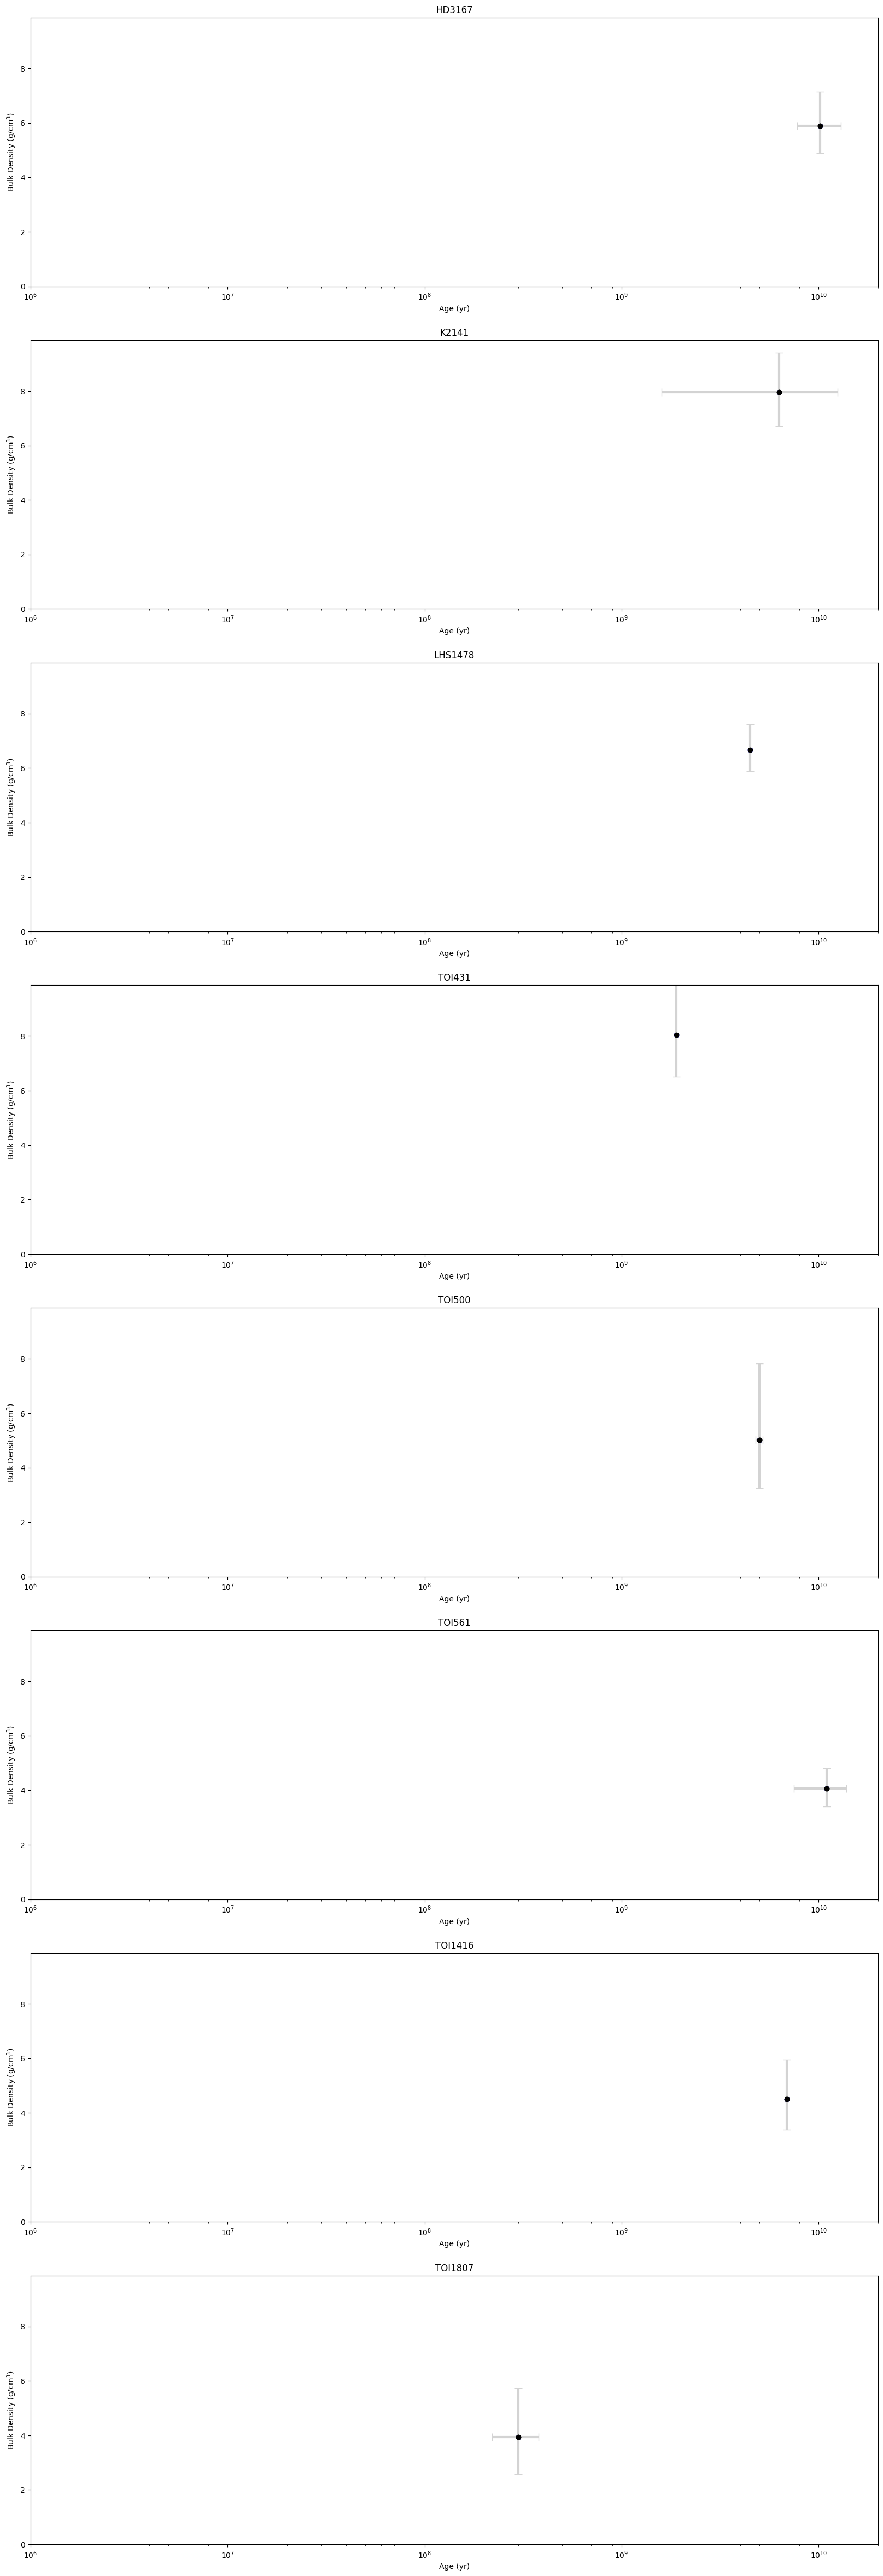

In [5]:
fig = figure(figsize=(20, 60))

for i, planet in enumerate(planet_names):
    frame = fig.add_subplot(8,1, i+1)
    frame.scatter(star_age[i], bulk_density_avg[i], color='blue')
    frame.errorbar(star_age[i], bulk_density_avg[i], yerr=([abs(bulk_density_min[i]-bulk_density_avg[i])], [abs(bulk_density_max[i]-bulk_density_avg[i])]), fmt='o', color='black', ecolor='lightgray', elinewidth=3, capsize=5)
    if planet != "LHS1478" and planet != "TOI431":
        frame.errorbar(star_age[i], bulk_density_avg[i], xerr=([abs(star_age_min[i]-star_age[i])], [abs(star_age_max[i]-star_age[i])]), fmt='o', color='black', ecolor='lightgray', elinewidth=3, capsize=5)

    frame.set_xscale('log')
    frame.invert_yaxis()

    frame.set_title(planet)

    frame.set_xlabel('Age (yr)')
    frame.set_ylabel('Bulk Density (g/cm$^3$)')

    frame.set_ylim(0,max(bulk_density_max)); frame.set_xlim(1e6,2e10)

show()